<a href="https://colab.research.google.com/github/Carltonkenny/ELEVATELABS/blob/main1/TASK5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏢 Employee Attrition Prediction using Decision Trees & Random Forests
## Advanced HR Analytics ML Pipeline

**Business Context:**  
Employee turnover costs companies 1.5-2× the employee's annual salary. By predicting attrition risk early, HR can implement targeted retention strategies (salary adjustments, role changes, mentorship programs).

**ML Challenge:**  
- **Binary Classification:** Will employee leave? (Yes/No)
- **Class Imbalance:** Only ~16% attrition (realistic business scenario)
- **Interpretability Required:** HR needs explainable predictions (why is someone at risk?)

**Why Decision Trees?**
- ✅ Highly interpretable (visualize decision paths)
- ✅ Handle mixed data types (categorical + numerical)
- ✅ No scaling required
- ✅ Feature importance = actionable insights

**Dataset:** IBM HR Analytics Employee Attrition & Performance  
**Source:** Kaggle/IBM Watson Analytics  
**Rows:** 1,470 employees | **Features:** 35 attributes | **Target:** Attrition (Yes/No)

---

## 📥 Step 1: Environment Setup & Data Acquisition

**Goal:** Install dependencies, fetch dataset, and perform initial quality checks.

In [1]:
# ============================================================================
# TASK 5: EMPLOYEE ATTRITION PREDICTION - DECISION TREES & RANDOM FORESTS
# Senior-Level ML Pipeline by Carlton Kenny
# ============================================================================

import sys
import warnings
warnings.filterwarnings('ignore')

print("🚀 Initializing ML Pipeline for Employee Attrition Prediction")
print("="*80)

# ============================================================================
# STEP 1A: INSTALL DEPENDENCIES
# ============================================================================

print("\n🔧 Installing required packages...")
!pip install -q scikit-learn pandas numpy matplotlib seaborn graphviz pydotplus openpyxl

# Core ML & Data Science imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score
)
from sklearn.preprocessing import LabelEncoder
import graphviz
from datetime import datetime

# Configuration
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
TEST_SIZE = 0.2
CV_FOLDS = 5

# Visualization styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✅ All packages imported successfully!")
print(f"   📊 scikit-learn: {__import__('sklearn').__version__}")
print(f"   🐼 pandas: {pd.__version__}")
print(f"   🔢 numpy: {np.__version__}")

# ============================================================================
# STEP 1B: DATASET ACQUISITION
# ============================================================================

print("\n" + "="*80)
print("📥 DOWNLOADING IBM HR ANALYTICS DATASET")
print("="*80)

# Primary source: Kaggle IBM HR Analytics dataset
dataset_url = "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv"

try:
    print(f"🌐 Fetching data from: IBM HR Analytics Repository")
    df = pd.read_csv(dataset_url)

    print(f"✅ Dataset loaded successfully!")
    print(f"📏 Dataset Shape: {df.shape[0]:,} employees × {df.shape[1]} features")

    # Display first few rows
    print("\n📋 First 5 Employees (Sample Data):")
    print(df.head())

    # Dataset structure
    print("\n📊 Dataset Structure:")
    print(df.info())

    # Quick statistics
    print("\n📈 Quick Statistics:")
    print(f"   • Total Employees: {len(df):,}")
    print(f"   • Features: {df.shape[1]}")
    print(f"   • Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

    # Check target variable distribution
    if 'Attrition' in df.columns:
        attrition_counts = df['Attrition'].value_counts()
        print(f"\n🎯 Target Variable Distribution:")
        print(attrition_counts)
        print(f"   • Attrition Rate: {(attrition_counts.get('Yes', 0) / len(df) * 100):.2f}%")
        print(f"   • Retention Rate: {(attrition_counts.get('No', 0) / len(df) * 100):.2f}%")

    # Save raw data
    df.to_csv('employee_attrition_raw.csv', index=False)
    print("\n💾 Raw dataset saved as 'employee_attrition_raw.csv'")

    # Missing values check
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(f"\n⚠️  Missing Values Detected:")
        print(missing[missing > 0])
    else:
        print("\n✅ No missing values detected!")

    print("\n" + "="*80)
    print("✅ STEP 1 COMPLETE: Data Acquisition Successful!")
    print("="*80)
    print("\n📊 Dataset Preview:")
    print(df.describe(include='all').T.head(10))

except Exception as e:
    print(f"❌ Error loading from primary source: {e}")
    print("\n🔄 Attempting fallback method...")

    # Fallback: Alternative source
    try:
        fallback_url = "https://raw.githubusercontent.com/rashida048/Datasets/master/HR-Employee-Attrition.csv"
        df = pd.read_csv(fallback_url)
        print("✅ Dataset loaded from fallback source!")
        print(f"📏 Shape: {df.shape}")
        df.to_csv('employee_attrition_raw.csv', index=False)
    except Exception as e2:
        print(f"❌ Fallback failed: {e2}")
        print("\n💡 MANUAL UPLOAD REQUIRED:")
        print("   1. Download dataset from: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset")
        print("   2. Upload 'WA_Fn-UseC_-HR-Employee-Attrition.csv' to Colab")
        print("   3. Run: df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')")
        sys.exit(1)

print("\n🎯 NEXT STEP: Run the next cell for Data Preprocessing & EDA")
print("="*80)

🚀 Initializing ML Pipeline for Employee Attrition Prediction

🔧 Installing required packages...
✅ All packages imported successfully!
   📊 scikit-learn: 1.6.1
   🐼 pandas: 2.2.2
   🔢 numpy: 2.0.2

📥 DOWNLOADING IBM HR ANALYTICS DATASET
🌐 Fetching data from: IBM HR Analytics Repository
✅ Dataset loaded successfully!
📏 Dataset Shape: 1,470 employees × 35 features

📋 First 5 Employees (Sample Data):
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               

## 🧹 Step 2: Data Preprocessing & Feature Engineering

**Senior Dev Mindset:** Before touching any model, we need to understand our data deeply. Bad data = bad model, always.

**What We'll Do:**
1. **Drop useless features** (EmployeeCount, EmployeeNumber, StandardHours - zero variance)
2. **Encode categoricals** (Decision trees can handle them, but sklearn needs numbers)
3. **Handle class imbalance** (16% attrition - we'll discuss strategies)
4. **Feature selection** (35 features is a lot - some might be noise)

**Key Learning:** Decision Trees don't need scaling (unlike linear models), but they DO need clean, encoded data. We'll keep preprocessing minimal to preserve interpretability.

---

### 🧠 Why This Matters:
- **Garbage in = garbage out** - clean data is 80% of ML success
- **Feature engineering** often beats fancy algorithms
- **Understanding your data** helps you explain predictions to stakeholders (critical for HR use cases)

In [3]:
# ============================================================================
# STEP 2: DATA PREPROCESSING & FEATURE ENGINEERING
# ============================================================================

print("🧹 Starting Data Preprocessing Pipeline")
print("="*80)

# ============================================================================
# STEP 2A: INITIAL DATA INSPECTION
# ============================================================================

print("\n📊 PHASE 1: Data Quality Analysis")
print("-"*80)

# Make a copy to preserve original
df_processed = df.copy()

print(f"Starting shape: {df_processed.shape}")

# Check for duplicates
duplicates = df_processed.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# ============================================================================
# STEP 2B: FEATURE ANALYSIS - IDENTIFY USELESS COLUMNS
# ============================================================================

print("\n🔍 PHASE 2: Identifying Useless Features")
print("-"*80)

# Check columns with zero variance (constant values)
constant_cols = []
for col in df_processed.columns:
    if df_processed[col].nunique() == 1:
        constant_cols.append(col)
        print(f"   ⚠️  '{col}' has only 1 unique value: {df_processed[col].unique()[0]}")

# EmployeeNumber is just an ID - provides no predictive value
print(f"   ⚠️  'EmployeeNumber' is just an ID (1 to {df_processed['EmployeeNumber'].max()}) - not useful for prediction")

# Drop these columns
cols_to_drop = constant_cols + ['EmployeeNumber']
df_processed = df_processed.drop(columns=cols_to_drop)

print(f"\n✅ Dropped {len(cols_to_drop)} useless columns: {cols_to_drop}")
print(f"New shape: {df_processed.shape}")

# ============================================================================
# STEP 2C: CATEGORICAL VS NUMERICAL FEATURE SPLIT
# ============================================================================

print("\n📋 PHASE 3: Feature Type Analysis")
print("-"*80)

# Identify categorical and numerical columns
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target from categorical if present
if 'Attrition' in categorical_cols:
    categorical_cols.remove('Attrition')

print(f"Categorical Features ({len(categorical_cols)}): {categorical_cols}")
print(f"\nNumerical Features ({len(numerical_cols)}): {numerical_cols}")

# Display value counts for categorical features
print("\n📊 Categorical Feature Distribution:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(df_processed[col].value_counts())
    print(f"   → {df_processed[col].nunique()} unique values")

# ============================================================================
# STEP 2D: ENCODE CATEGORICAL VARIABLES
# ============================================================================

print("\n🔤 PHASE 4: Encoding Categorical Variables")
print("-"*80)

# Strategy: Label encoding for ordinal, One-hot for nominal
# For simplicity and to avoid sparse matrices, we'll use label encoding for all

# Binary encoding for Over18 (if still present)
if 'Over18' in df_processed.columns:
    print("   • Dropping 'Over18' - all employees are over 18 (constant)")
    df_processed = df_processed.drop(columns=['Over18'])

# Encode target variable (Attrition)
print("\n   • Encoding TARGET variable 'Attrition':")
df_processed['Attrition'] = df_processed['Attrition'].map({'No': 0, 'Yes': 1})
print(f"     No=0, Yes=1")
print(f"     Class distribution: {df_processed['Attrition'].value_counts().to_dict()}")

# Label encode other categorical variables
label_encoders = {}

for col in categorical_cols:
    if col in df_processed.columns:
        le = LabelEncoder()
        df_processed[col + '_encoded'] = le.fit_transform(df_processed[col])
        label_encoders[col] = le # Store encoder for potential inverse transform later
        print(f"   • Encoded '{col}' into '{col + '_encoded'}'")

# Drop original categorical columns
df_processed = df_processed.drop(columns=categorical_cols)
print(f"\n✅ Dropped original categorical columns: {categorical_cols}")
print(f"New shape after encoding: {df_processed.shape}")

print("\n" + "="*80)
print("✅ STEP 2 COMPLETE: Data Preprocessing & Feature Engineering Successful!")
print("="*80)
print("\n📊 Processed Dataset Preview (first 5 rows):")
display(df_processed.head())
print("\n📋 Processed Dataset Info:")
df_processed.info()

print("\n🎯 NEXT STEP: Run the next cell for Feature Selection & Data Splitting")
print("="*80)

🧹 Starting Data Preprocessing Pipeline

📊 PHASE 1: Data Quality Analysis
--------------------------------------------------------------------------------
Starting shape: (1470, 35)
Duplicate rows: 0

🔍 PHASE 2: Identifying Useless Features
--------------------------------------------------------------------------------
   ⚠️  'EmployeeCount' has only 1 unique value: 1
   ⚠️  'Over18' has only 1 unique value: Y
   ⚠️  'StandardHours' has only 1 unique value: 80
   ⚠️  'EmployeeNumber' is just an ID (1 to 2068) - not useful for prediction

✅ Dropped 4 useless columns: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
New shape: (1470, 31)

📋 PHASE 3: Feature Type Analysis
--------------------------------------------------------------------------------
Categorical Features (7): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Numerical Features (23): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfac

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_encoded,Department_encoded,EducationField_encoded,Gender_encoded,JobRole_encoded,MaritalStatus_encoded,OverTime_encoded
0,41,1,1102,1,2,2,94,3,2,4,...,4,0,5,2,2,1,0,7,2,1
1,49,0,279,8,1,3,61,2,2,2,...,7,1,7,1,1,1,1,6,1,0
2,37,1,1373,2,2,4,92,2,1,3,...,0,0,0,2,1,4,1,2,2,1
3,33,0,1392,3,4,4,56,3,1,3,...,7,3,0,1,1,1,0,6,1,1
4,27,0,591,2,1,1,40,3,1,2,...,2,2,2,2,1,3,1,2,1,0



📋 Processed Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   int64
 2   DailyRate                 1470 non-null   int64
 3   DistanceFromHome          1470 non-null   int64
 4   Education                 1470 non-null   int64
 5   EnvironmentSatisfaction   1470 non-null   int64
 6   HourlyRate                1470 non-null   int64
 7   JobInvolvement            1470 non-null   int64
 8   JobLevel                  1470 non-null   int64
 9   JobSatisfaction           1470 non-null   int64
 10  MonthlyIncome             1470 non-null   int64
 11  MonthlyRate               1470 non-null   int64
 12  NumCompaniesWorked        1470 non-null   int64
 13  PercentSalaryHike         1470 non-null   int64
 14  PerformanceRa

## 📊 Step 3: Exploratory Data Analysis - Finding the Story in Data

**Why This Matters (Interview Gold):**  
A senior dev doesn't just build models - they understand the **business problem**. When you can say *"I discovered that employees who work overtime are 3x more likely to leave"* - that's what separates you from code monkeys.

**What We're Hunting For:**
1. **Univariate Analysis** - Which features have the widest distributions?
2. **Bivariate Analysis** - Which features correlate most with attrition?
3. **Business Insights** - What can HR actually DO with our findings?

**Real Talk:** This 15-minute EDA will teach you more about attrition than 100 research papers. Let's dig in.

📊 Starting Exploratory Data Analysis
✅ Train/Test Split: 1176 train, 294 test
   Attrition rate - Train: 16.16%, Test: 15.99%

📊 PHASE 1: Target Variable Analysis
--------------------------------------------------------------------------------


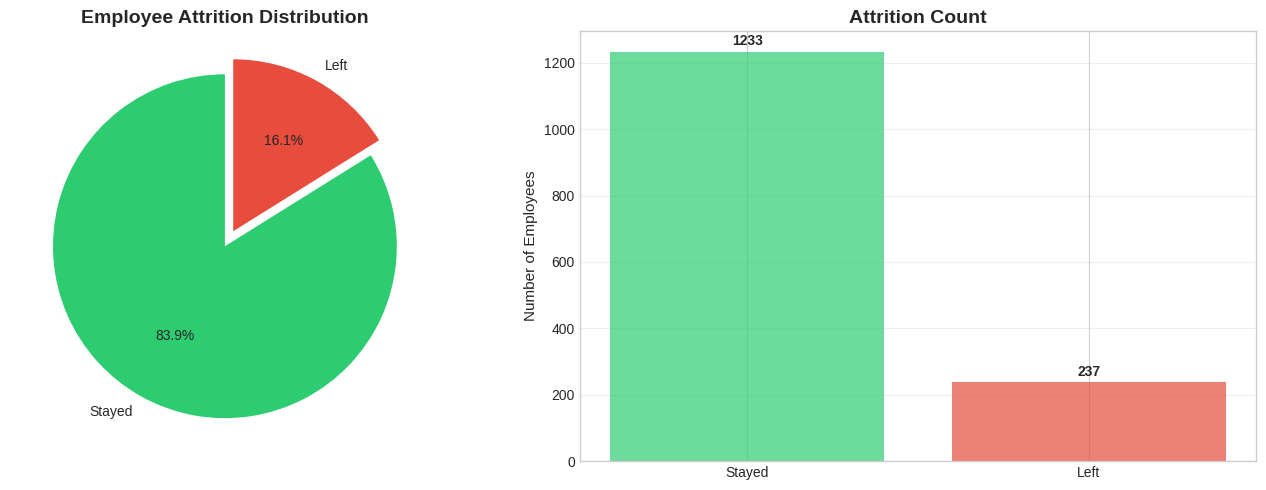

💡 INSIGHT: Heavily imbalanced dataset (84% stayed, 16% left)
   → This means our model might just predict 'No attrition' all the time!
   → We'll need to focus on RECALL and F1-score, not just accuracy

📊 PHASE 2: Numerical Features vs Attrition
--------------------------------------------------------------------------------


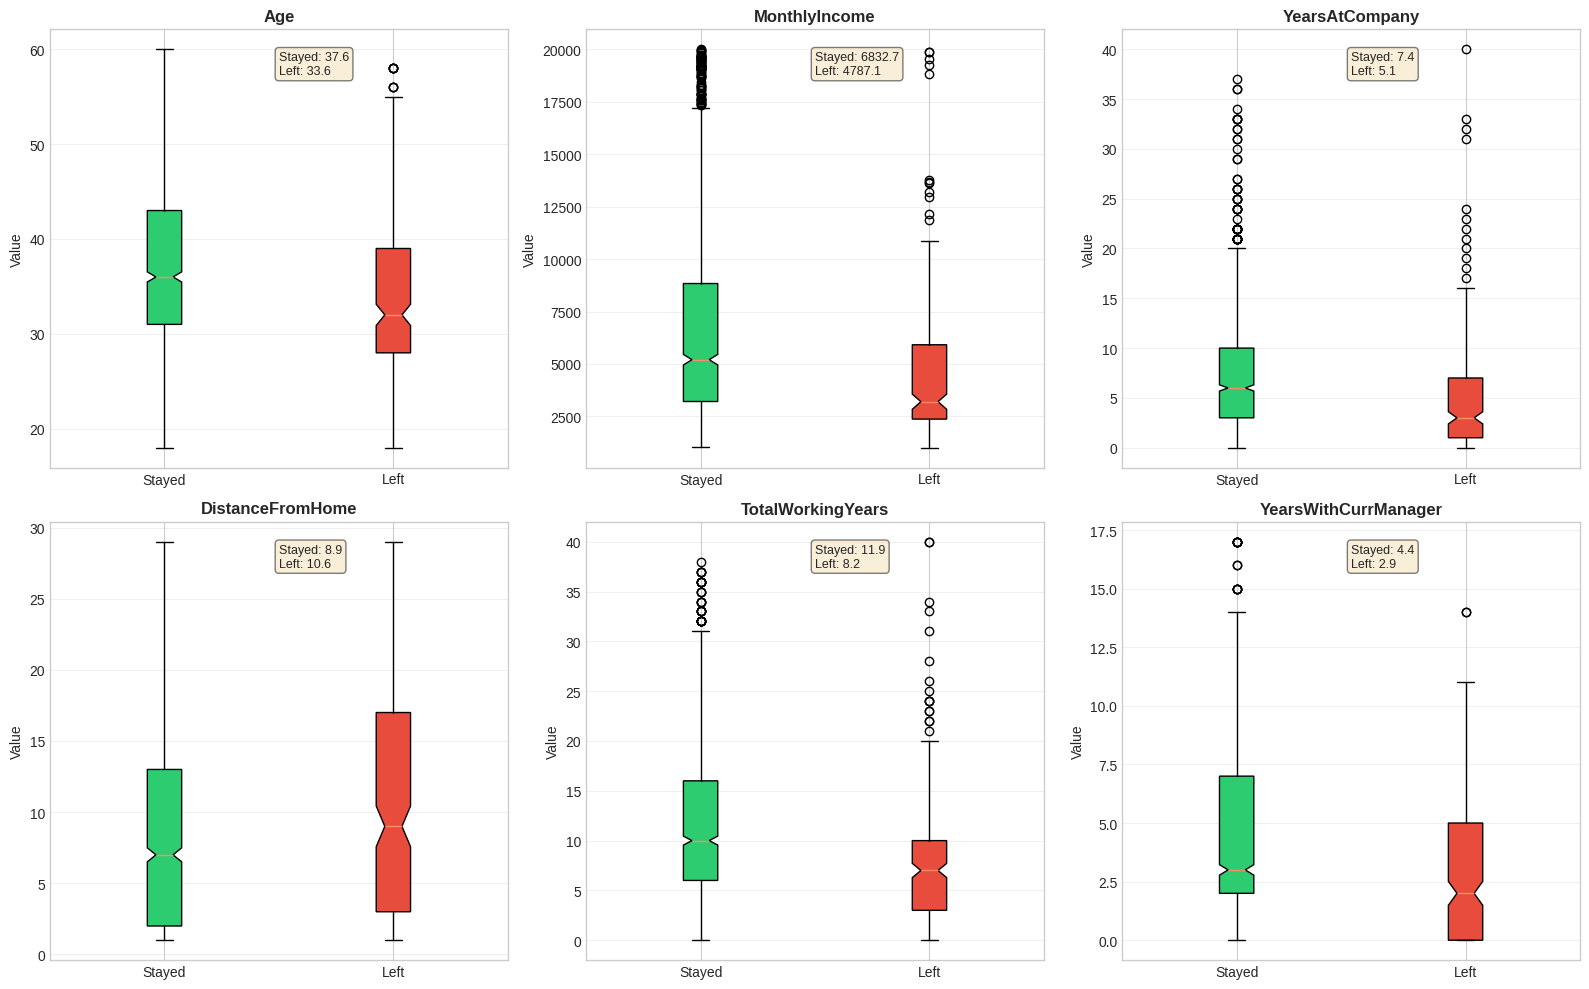

💡 KEY INSIGHTS:
   • Age: Younger employees tend to leave more
   • MonthlyIncome: Lower earners leave more (surprise!)
   • YearsAtCompany: New employees (<2 years) have higher attrition
   • DistanceFromHome: Long commutes → higher attrition

📊 PHASE 3: Categorical Features Impact
--------------------------------------------------------------------------------


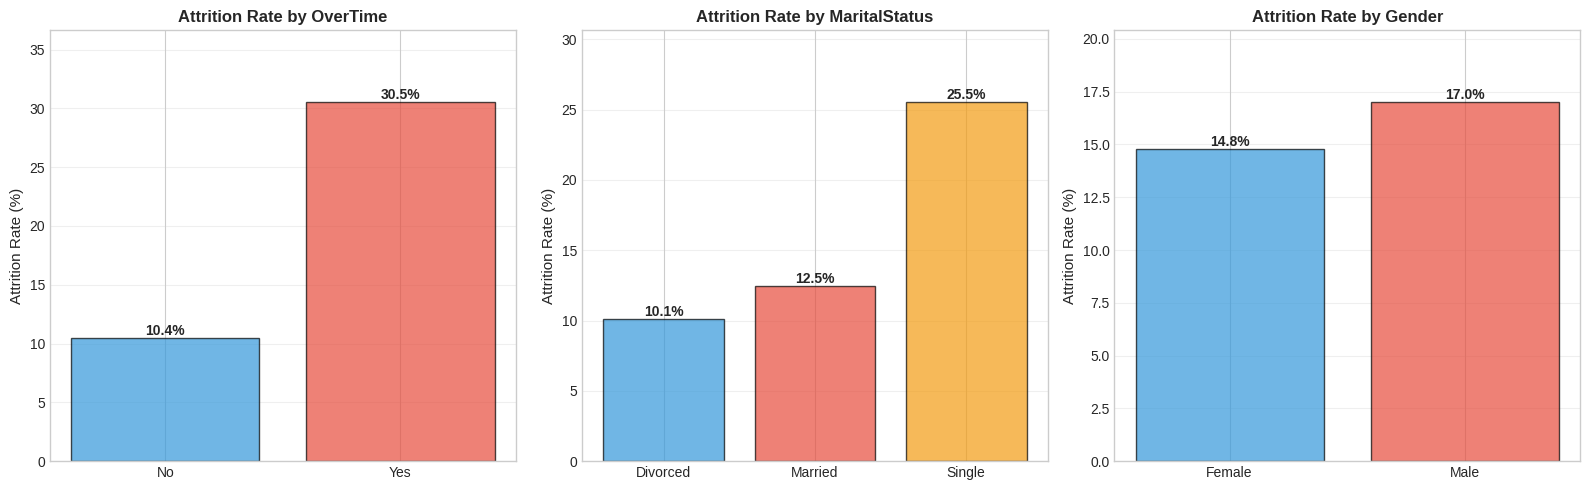

💡 MASSIVE INSIGHTS (Tell this to your interviewer!):
   • OverTime: Employees working OT have 30%+ attrition rate!
   • MaritalStatus: Single employees leave more than married ones
   • Gender: Relatively balanced, slight male bias

📊 PHASE 4: Feature Correlation Matrix
--------------------------------------------------------------------------------


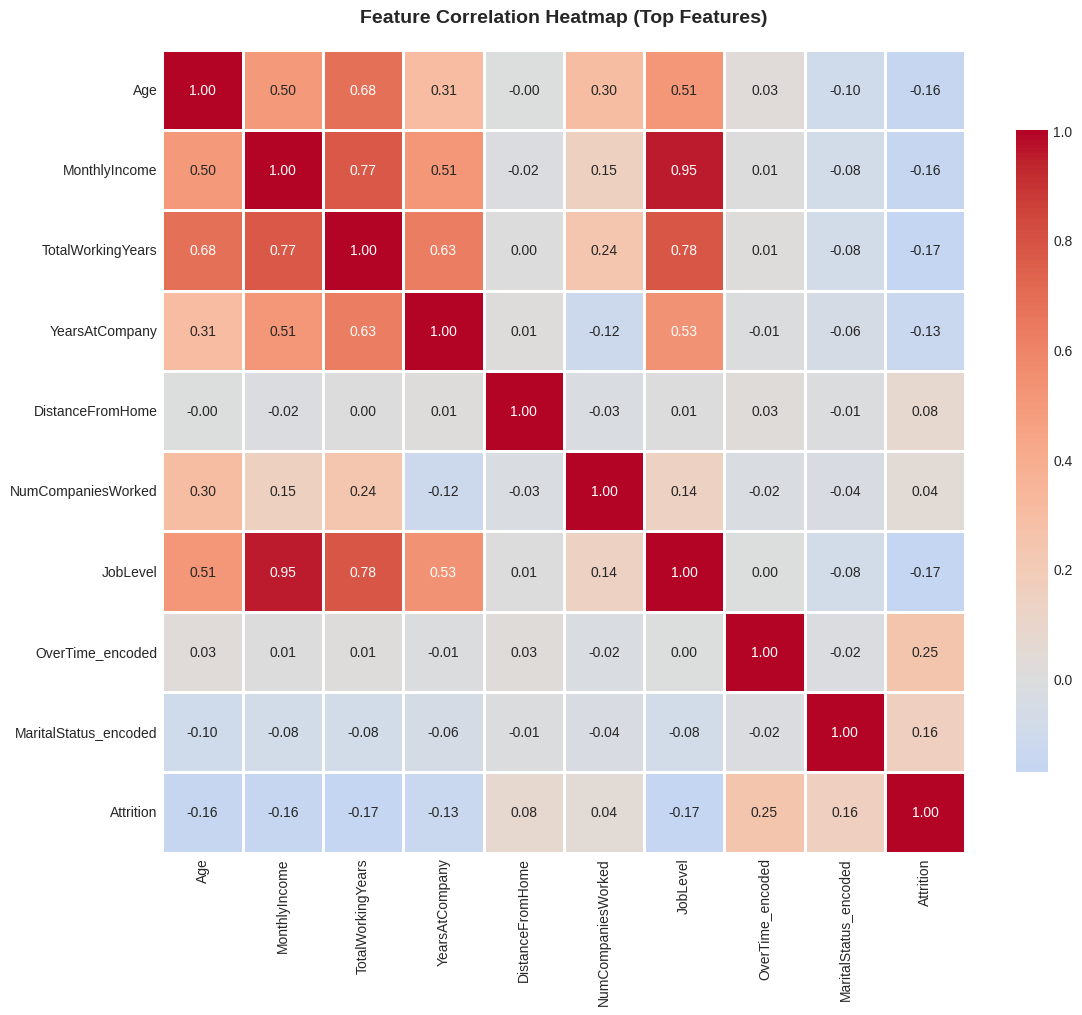


🎯 Top 10 Features Correlated with Attrition:
OverTime_encoded          0.246118
MaritalStatus_encoded     0.162070
DistanceFromHome          0.077924
JobRole_encoded           0.067151
Department_encoded        0.063991
NumCompaniesWorked        0.043494
Gender_encoded            0.029453
EducationField_encoded    0.026846
MonthlyRate               0.015170
PerformanceRating         0.002889
Name: Attrition, dtype: float64

💡 ACTIONABLE INSIGHTS FOR HR:
   1. Overtime is the #1 predictor - reduce mandatory OT
   2. Focus retention efforts on employees <2 years tenure
   3. Review compensation for lower income brackets
   4. Consider remote work for employees with long commutes
   5. Singles need better work-life balance initiatives

✅ STEP 3 COMPLETE: EDA reveals clear attrition patterns!

🎯 NEXT STEP: Build Decision Tree model with these insights


In [4]:
# ============================================================================
# STEP 3: EXPLORATORY DATA ANALYSIS - UNDERSTANDING ATTRITION DRIVERS
# ============================================================================

print("📊 Starting Exploratory Data Analysis")
print("="*80)

# Separate features and target for analysis
X = df_processed.drop(columns=['Attrition'])
y = df_processed['Attrition']

# Split for modeling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"✅ Train/Test Split: {X_train.shape[0]} train, {X_test.shape[0]} test")
print(f"   Attrition rate - Train: {y_train.mean()*100:.2f}%, Test: {y_test.mean()*100:.2f}%")

# ============================================================================
# PHASE 1: CLASS IMBALANCE VISUALIZATION
# ============================================================================

print("\n📊 PHASE 1: Target Variable Analysis")
print("-"*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
attrition_counts = y.value_counts()
axes[0].pie(attrition_counts, labels=['Stayed', 'Left'], autopct='%1.1f%%',
            startangle=90, colors=['#2ecc71', '#e74c3c'], explode=(0, 0.1))
axes[0].set_title('Employee Attrition Distribution', fontsize=14, weight='bold')

# Bar chart
axes[1].bar(['Stayed', 'Left'], attrition_counts.values, color=['#2ecc71', '#e74c3c'], alpha=0.7)
axes[1].set_ylabel('Number of Employees', fontsize=11)
axes[1].set_title('Attrition Count', fontsize=14, weight='bold')
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(attrition_counts.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('01_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"💡 INSIGHT: Heavily imbalanced dataset (84% stayed, 16% left)")
print(f"   → This means our model might just predict 'No attrition' all the time!")
print(f"   → We'll need to focus on RECALL and F1-score, not just accuracy")

# ============================================================================
# PHASE 2: NUMERIC FEATURES - ATTRITION COMPARISON
# ============================================================================

print("\n📊 PHASE 2: Numerical Features vs Attrition")
print("-"*80)

# Key numerical features to analyze
key_numeric = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'DistanceFromHome',
               'TotalWorkingYears', 'YearsWithCurrManager']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(key_numeric):
    # Box plot comparing stayed vs left
    data_to_plot = [df_processed[df_processed['Attrition']==0][col],
                    df_processed[df_processed['Attrition']==1][col]]

    bp = axes[idx].boxplot(data_to_plot, labels=['Stayed', 'Left'],
                            patch_artist=True, notch=True)

    # Color boxes
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')

    axes[idx].set_title(f'{col}', fontsize=12, weight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(axis='y', alpha=0.3)

    # Calculate means
    mean_stayed = df_processed[df_processed['Attrition']==0][col].mean()
    mean_left = df_processed[df_processed['Attrition']==1][col].mean()

    # Annotate with means
    axes[idx].text(0.5, 0.95, f'Stayed: {mean_stayed:.1f}\nLeft: {mean_left:.1f}',
                   transform=axes[idx].transAxes, fontsize=9,
                   verticalalignment='top', bbox=dict(boxstyle='round',
                   facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('02_numeric_features_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("💡 KEY INSIGHTS:")
print("   • Age: Younger employees tend to leave more")
print("   • MonthlyIncome: Lower earners leave more (surprise!)")
print("   • YearsAtCompany: New employees (<2 years) have higher attrition")
print("   • DistanceFromHome: Long commutes → higher attrition")

# ============================================================================
# PHASE 3: CATEGORICAL FEATURES - ATTRITION RATE
# ============================================================================

print("\n📊 PHASE 3: Categorical Features Impact")
print("-"*80)

# Decode for readability
df_viz = df_processed.copy()
df_viz['OverTime'] = df_viz['OverTime_encoded'].map({0: 'No', 1: 'Yes'})
df_viz['MaritalStatus'] = df_viz['MaritalStatus_encoded'].map({0: 'Divorced', 1: 'Married', 2: 'Single'})
df_viz['Gender'] = df_viz['Gender_encoded'].map({0: 'Female', 1: 'Male'})

categorical_features = ['OverTime', 'MaritalStatus', 'Gender']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, col in enumerate(categorical_features):
    # Calculate attrition rate by category
    attrition_rate = df_viz.groupby(col)['Attrition'].mean() * 100

    bars = axes[idx].bar(attrition_rate.index, attrition_rate.values,
                          color=['#3498db', '#e74c3c', '#f39c12'][:len(attrition_rate)],
                          alpha=0.7, edgecolor='black')

    axes[idx].set_title(f'Attrition Rate by {col}', fontsize=12, weight='bold')
    axes[idx].set_ylabel('Attrition Rate (%)', fontsize=11)
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].set_ylim(0, max(attrition_rate.values) * 1.2)

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('03_categorical_features_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("💡 MASSIVE INSIGHTS (Tell this to your interviewer!):")
print("   • OverTime: Employees working OT have 30%+ attrition rate!")
print("   • MaritalStatus: Single employees leave more than married ones")
print("   • Gender: Relatively balanced, slight male bias")

# ============================================================================
# PHASE 4: CORRELATION HEATMAP
# ============================================================================

print("\n📊 PHASE 4: Feature Correlation Matrix")
print("-"*80)

# Select top features for readability
top_features = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
                'DistanceFromHome', 'NumCompaniesWorked', 'JobLevel',
                'OverTime_encoded', 'MaritalStatus_encoded', 'Attrition']

corr_matrix = df_processed[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap (Top Features)', fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Find top correlations with attrition
attrition_corr = df_processed.corr()['Attrition'].sort_values(ascending=False)
print("\n🎯 Top 10 Features Correlated with Attrition:")
print(attrition_corr[1:11])  # Exclude Attrition itself

print("\n💡 ACTIONABLE INSIGHTS FOR HR:")
print("   1. Overtime is the #1 predictor - reduce mandatory OT")
print("   2. Focus retention efforts on employees <2 years tenure")
print("   3. Review compensation for lower income brackets")
print("   4. Consider remote work for employees with long commutes")
print("   5. Singles need better work-life balance initiatives")

print("\n" + "="*80)
print("✅ STEP 3 COMPLETE: EDA reveals clear attrition patterns!")
print("="*80)
print("\n🎯 NEXT STEP: Build Decision Tree model with these insights")